# GrowSari — Demand Forecasting (v3, input-driven)

**Run order: top to bottom.** This version is driven by an interactive **input panel** — you do not edit code.
You provide six inputs:

1. **Aggregation level** — one of `WH_SKU`, `WH_Category`, `WH_SKU_Channel`, `WH_Category_Channel`.
2. **Combinations** — an **Excel upload** listing the exact series to forecast, with columns matching the level (a one-click template is generated for you).
3. **Temporal aggregation** — modeling grain for train/test/forecast (keep **daily** for now; weekly/monthly unlock with more history).
4. **Test period** — a **month picker** over historical months (the held-out window used to pick the best model).
5. **Forecast granularity** — equal to or coarser than the modeling grain — **and** a **forecast period** (start→end month). The forecast is produced at the chosen granularity for the chosen month(s).

The engine runs **all models**, scores them on the test month(s), auto-selects the **champion** per series, then produces the forward forecast for the selected window. It can take a while for many combinations — that is expected.


## 1 · Install & imports

In [ ]:
# Colab: uncomment on first run
# !pip install -q pandas numpy scikit-learn xgboost lightgbm statsmodels openpyxl matplotlib ipywidgets boto3 botocore
import warnings, time, io, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from datetime import datetime
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
try:
    import ipywidgets as W
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
print("ready · widgets:", HAS_WIDGETS)

ready · widgets: True


## 2 · Engine — holiday calendar + adaptive classification

In [ ]:
# ===================================================================== #
#  PHILIPPINE HOLIDAY CALENDAR  (2024-2026 verified + auto-extend)       #
# ===================================================================== #
# Movable holidays (Holy Week, Chinese New Year, Eid, Black Saturday) — verified per
# Proclamations 368/727/1006. Eid dates are approximate until separately proclaimed.
_MOVABLE = {
    2024: {"2024-02-10": "Chinese New Year", "2024-03-28": "Maundy Thursday",
           "2024-03-29": "Good Friday", "2024-03-30": "Black Saturday",
           "2024-04-10": "Eidul Fitr", "2024-06-17": "Eidul Adha"},
    2025: {"2025-01-29": "Chinese New Year", "2025-04-17": "Maundy Thursday",
           "2025-04-18": "Good Friday", "2025-04-19": "Black Saturday",
           "2025-03-31": "Eidul Fitr", "2025-06-06": "Eidul Adha",
           "2025-07-27": "INC Founding"},
    2026: {"2026-02-17": "Chinese New Year", "2026-04-02": "Maundy Thursday",
           "2026-04-03": "Good Friday", "2026-04-04": "Black Saturday",
           "2026-03-20": "Eidul Fitr", "2026-05-27": "Eidul Adha",
           "2026-02-25": "EDSA (special working)"},
}
# regular holidays that move slightly handled above; the rest are fixed-date
_FIXED_REGULAR = {"01-01": "New Year's Day", "04-09": "Araw ng Kagitingan",
                  "05-01": "Labor Day", "06-12": "Independence Day",
                  "11-30": "Bonifacio Day", "12-25": "Christmas Day", "12-30": "Rizal Day"}
_FIXED_SPECIAL = {"08-21": "Ninoy Aquino Day", "11-01": "All Saints' Day",
                  "11-02": "All Souls' Day", "12-08": "Immaculate Conception",
                  "12-24": "Christmas Eve", "12-31": "Last Day of Year"}


def _last_monday_august(year):
    d = pd.Timestamp(year, 8, 31)
    return d - pd.Timedelta(days=(d.dayofweek - 0) % 7)


def build_ph_holidays(year_min, year_max):
    """Return dict {Timestamp: (name, 'regular'|'special')} spanning the year range."""
    out = {}
    for y in range(year_min, year_max + 1):
        for mmdd, nm in _FIXED_REGULAR.items():
            out[pd.Timestamp(f"{y}-{mmdd}")] = (nm, "regular")
        for mmdd, nm in _FIXED_SPECIAL.items():
            out[pd.Timestamp(f"{y}-{mmdd}")] = (nm, "special")
        out[_last_monday_august(y)] = ("National Heroes Day", "regular")
        for ds, nm in _MOVABLE.get(y, {}).items():
            kind = "special" if ("special" in nm or "Black" in nm or "CNY" in nm
                                 or "New Year" in nm or "INC" in nm or "EDSA" in nm) else "regular"
            # Holy Week Thu/Fri & Eid are regular; CNY/Black Saturday/INC/EDSA special
            if nm in ("Maundy Thursday", "Good Friday", "Eidul Fitr", "Eidul Adha"):
                kind = "regular"
            else:
                kind = "special"
            out[pd.Timestamp(ds)] = (nm, kind)
    return out


# ===================================================================== #
#  TRADING CALENDAR  (data-driven: closed weekdays auto-detected)        #
# ===================================================================== #
# NOTE (fix): v3 hard-coded Sunday as closed. This data has real Sunday demand,
# so closed_dows now defaults to () = open every day and is auto-detected from
# the data after load (see detect_closed_dows in the next engine cell).
def trading_days_between(start, end, closed_dows=()):
    """Count trading days in [start, end] excluding closed weekdays (default: none)."""
    rng = pd.date_range(start, end, freq="D")
    return int(sum(d.dayofweek not in closed_dows for d in rng))


# ===================================================================== #
#  ADAPTIVE DEMAND CLASSIFICATION  (Syntetos-Boylan + ABC + lifecycle)  #
# ===================================================================== #
DEFAULT_PARAMS = dict(
    abc_a=0.80, abc_b=0.95,
    adi_cut=1.32, cv2_cut=0.49,
    new_history_days=60,        # auto-scaled if history is long
    dormant_recency_days=28,    # auto-scaled
    closed_dows=(),             # auto-detected after load (was (6,) = Sunday closed)
    seasonality_min_cycles=2,   # need >=2 cycles to assess seasonality
)


def _series_metrics(daily_y, dates, ref_date, params):
    """Compute SB + lifecycle metrics for one series given its daily demand vector.
    History is the series' OWN active window (first demand -> ref_date) in trading days."""
    demand_days = int((daily_y > 0).sum())
    nonzero = daily_y[daily_y > 0]
    total = float(daily_y.sum())
    first_demand = dates[daily_y > 0].min() if demand_days > 0 else dates.min()
    history_td = trading_days_between(first_demand, ref_date, params["closed_dows"])
    # ADI = avg interval between demands (in trading-day units), over the series' active window
    adi = history_td / demand_days if demand_days > 0 else np.inf
    cv2 = float((nonzero.std(ddof=0) / nonzero.mean()) ** 2) if demand_days > 1 and nonzero.mean() > 0 else 0.0
    last_demand = dates[daily_y > 0].max() if demand_days > 0 else None
    recency_td = trading_days_between(last_demand, ref_date, params["closed_dows"]) - 1 if last_demand is not None else 9999
    coverage = demand_days / history_td if history_td > 0 else 0.0
    return dict(total_units=total, demand_days=demand_days, history_td=history_td,
                recency_td=max(recency_td, 0), coverage=coverage, adi=adi, cv2=cv2)


def _seasonality_trend(y, period):
    """Strength of seasonality & trend via STL (returns 0..1 each). Needs >=2 periods."""
    if period < 2 or len(y) < 2 * period + 1 or (y > 0).sum() < period:
        return np.nan, np.nan
    try:
        from statsmodels.tsa.seasonal import STL
        res = STL(np.where(y <= 0, 1e-6, y), period=period, robust=True).fit()
        var_resid = np.var(res.resid)
        s_strength = max(0.0, 1 - var_resid / max(np.var(res.resid + res.seasonal), 1e-9))
        t_strength = max(0.0, 1 - var_resid / max(np.var(res.resid + res.trend), 1e-9))
        return round(float(s_strength), 3), round(float(t_strength), 3)
    except Exception:
        return np.nan, np.nan


def _pattern(adi, cv2, p):
    if adi <= p["adi_cut"] and cv2 <= p["cv2_cut"]: return "Smooth"
    if adi <= p["adi_cut"] and cv2 >  p["cv2_cut"]: return "Erratic"
    if adi >  p["adi_cut"] and cv2 <= p["cv2_cut"]: return "Intermittent"
    return "Lumpy"


def _recommend_method(seg, has_yoy, s_strength):
    seasonal = (has_yoy and (s_strength or 0) >= 0.3)
    table = {
        "Smooth":       ("ETS/LightGBM + seasonal features" if seasonal else "ETS/LightGBM + day-of-week", "daily"),
        "Erratic":      ("Quantile GBM / ETS damped on weekly buckets", "weekly"),
        "Intermittent": ("Croston / SBA / TSB", "weekly"),
        "Lumpy":        ("TSB / empirical resampling", "weekly/monthly"),
        "Dormant":      ("Exclude from active forecasting", "—"),
        "New":          ("Category-proxy disaggregation", "daily proxy"),
    }
    return table.get(seg, ("ETS", "daily"))


def classify_level(demand, group_keys, ref_date, params=None, name_col="name",
                   category_col="category", seasonal_period_daily=None):
    """
    Classify all series at one aggregation level.
    demand: long df with date, warehouse_id, channel, sku_id, category, name, y
    group_keys: subset of [warehouse_id, sku_id, category, channel] defining the grain.
    Returns a tidy classification DataFrame.
    """
    p = {**DEFAULT_PARAMS, **(params or {})}
    ref_date = pd.Timestamp(ref_date)
    span_start, span_end = demand["date"].min(), ref_date
    history_td = trading_days_between(span_start, span_end, p["closed_dows"])

    # ---- adapt thresholds to available history ----
    hist_days = (span_end - span_start).days
    if hist_days >= 540:            # ~1.5+ yr -> longer windows are meaningful
        p["new_history_days"] = max(p["new_history_days"], 90)
        p["dormant_recency_days"] = max(p["dormant_recency_days"], 42)
    has_yoy = hist_days >= 700      # ~2 years -> YoY seasonal models unlockable
    sp = seasonal_period_daily or (7 - len(p["closed_dows"]))   # 6 for Mon-Sat

    g = demand.groupby(group_keys + ["date"])["y"].sum().reset_index()
    rows = []
    for key, sub in g.groupby(group_keys):
        key = key if isinstance(key, tuple) else (key,)
        s = sub.set_index("date")["y"].sort_index()
        dates = s.index
        m = _series_metrics(s.values, dates, ref_date, p)
        # lifecycle
        if m["demand_days"] == 0 or m["recency_td"] > p["dormant_recency_days"]:
            lifecycle = "Dormant"
        elif m["history_td"] < p["new_history_days"]:
            lifecycle = "New"
        else:
            lifecycle = "Active"
        pattern = _pattern(m["adi"], m["cv2"], p) if lifecycle == "Active" else None
        segment = lifecycle if lifecycle != "Active" else pattern
        s_str, t_str = (_seasonality_trend(s.reindex(
            pd.date_range(dates.min(), dates.max())).fillna(0).values, sp)
            if lifecycle == "Active" else (np.nan, np.nan))
        rec_method, rec_grain = _recommend_method(segment, has_yoy, s_str)
        rowd = dict(zip(group_keys, key))
        rowd.update(m)
        rowd.update(dict(lifecycle=lifecycle, pattern=pattern, segment=segment,
                         seasonality_strength=s_str, trend_strength=t_str,
                         has_yoy=has_yoy, rec_method=rec_method, rec_grain=rec_grain))
        rows.append(rowd)
    out = pd.DataFrame(rows)

    # ---- ABC within level ----
    out = out.sort_values("total_units", ascending=False).reset_index(drop=True)
    grand = out["total_units"].sum()
    out["units_share"] = out["total_units"] / grand if grand > 0 else 0
    out["cum_share"] = out["units_share"].cumsum()
    prev = out["cum_share"] - out["units_share"]
    out["ABC"] = np.where(prev < p["abc_a"], "A", np.where(prev < p["abc_b"], "B", "C"))
    out["coverage_pct"] = (out["coverage"] * 100).round(1)
    out["adi"] = out["adi"].round(3); out["cv2"] = out["cv2"].round(4)
    return out


LEVEL_KEYS = {
    "WH_SKU":              ["warehouse_id", "sku_id"],
    "WH_Category":         ["warehouse_id", "category"],
    "WH_SKU_Channel":      ["warehouse_id", "sku_id", "channel"],
    "WH_Category_Channel": ["warehouse_id", "category", "channel"],
}


def classify_all(demand, ref_date, params=None, levels=None):
    levels = levels or list(LEVEL_KEYS)
    return {lv: classify_level(demand, LEVEL_KEYS[lv], ref_date, params) for lv in levels}

## 3 · Engine — series, features, model library, metrics

In [ ]:
GRAIN_ORDER = {"daily": 0, "weekly": 1, "monthly": 2}

# --- Trading calendar is DATA-DRIVEN (fix) ------------------------------ #
# v3 hard-coded CLOSED_DOWS=(6,) ("Sunday closed"). build_daily_series,
# _future_periods and seasonal_period all key off TRADING_DOW, so every Sunday
# was dropped from the series grid, the May test window (-> 26 instead of 31
# points) and the forecast horizon, and the backtest actual total came out
# LOWER than the true historical demand. This dataset has genuine Sunday sales,
# so we default to open-every-day and auto-detect any truly-closed weekday.
CLOSED_DOWS = ()                          # reassigned by detect_closed_dows() after load
TRADING_DOW = tuple(d for d in range(7) if d not in CLOSED_DOWS)

def detect_closed_dows(demand_df, rel_threshold=0.02):
    """A weekday (0=Mon..6=Sun) is CLOSED only if its TOTAL demand across the whole
    dataset is <= rel_threshold x the median open-weekday total. Returns () for
    7-day data, (6,) for genuine Mon-Sat data, etc."""
    by = demand_df.groupby(demand_df["date"].dt.dayofweek)["y"].sum().reindex(range(7), fill_value=0.0)
    open_med = by[by > 0].median() if (by > 0).any() else 0.0
    return tuple(int(d) for d in range(7) if by[d] <= rel_threshold * open_med)
MIN_OBS_ML = {"daily": 24, "weekly": 12, "monthly": 18}   # below this -> skip ML

# ===================================================================== #
#  SERIES BUILD + TEMPORAL RESAMPLE                                      #
# ===================================================================== #
def build_daily_series(sub):
    """sub: rows for ONE series with date,y[,availability]. Dense Mon-Sat grid, 0-fill."""
    s = sub.groupby("date").agg(y=("y", "sum"),
                                availability=("availability", "mean")).reset_index()
    full = pd.date_range(s["date"].min(), s["date"].max(), freq="D")
    full = full[[d.dayofweek in TRADING_DOW for d in full]]
    out = pd.DataFrame({"ds": full}).merge(s.rename(columns={"date": "ds"}), on="ds", how="left")
    out["y"] = out["y"].fillna(0.0)
    out["availability"] = out["availability"].fillna(1.0)
    return out


def resample_grain(daily, grain, holidays):
    """Aggregate a daily series to daily/weekly/monthly with calendar counts."""
    d = daily.copy()
    if grain == "daily":
        d["n_trading"] = 1
        d["n_holiday"] = d["ds"].isin(holidays).astype(int)
        return d
    if grain == "weekly":
        d["bucket"] = d["ds"] - pd.to_timedelta(d["ds"].dt.dayofweek, unit="D")
    else:  # monthly
        d["bucket"] = d["ds"].values.astype("datetime64[M]")
    agg = (d.groupby("bucket")
           .agg(y=("y", "sum"), availability=("availability", "mean"),
                n_trading=("y", "size"),
                n_holiday=("ds", lambda x: sum(t in holidays for t in x)))
           .reset_index().rename(columns={"bucket": "ds"}).sort_values("ds"))
    return agg


def grain_to_bucket(ds_series, to_grain):
    if to_grain == "daily":   return ds_series
    if to_grain == "weekly":  return ds_series - pd.to_timedelta(ds_series.dt.dayofweek, unit="D")
    return ds_series.values.astype("datetime64[M]")


def seasonal_period(grain, history_len):
    base = {"daily": len(TRADING_DOW), "weekly": 52, "monthly": 12}[grain]
    return base if history_len >= 2 * base + 1 else None


# ===================================================================== #
#  FEATURE ENGINEERING (grain-aware)                                    #
# ===================================================================== #
def add_features(df, grain, holidays, reg_dates, spc_dates):
    d = df.copy().reset_index(drop=True)
    ds = d["ds"]
    if grain == "daily":
        d["dow"] = ds.dt.dayofweek; d["day"] = ds.dt.day; d["month"] = ds.dt.month
        d["weekofmonth"] = (ds.dt.day - 1)//7 + 1
        d["is_payday"] = ds.dt.day.isin(list(range(13,17))+list(range(29,32))+[1,2]).astype(int)
        d["is_holiday"] = ds.isin(holidays).astype(int)
        d["is_reg_hol"] = ds.isin(reg_dates).astype(int)
        d["is_spc_hol"] = ds.isin(spc_dates).astype(int)
        hs = sorted(holidays)
        d["pre_hol"]  = [1 if any(0 < (h-t).days <= 3 for h in hs) else 0 for t in ds]
        d["post_hol"] = [1 if any(0 < (t-h).days <= 2 for h in hs) else 0 for t in ds]
        lags, rolls = (1,2,3,6,12,18), (3,6,12,24)
        seas = "dow"
    elif grain == "weekly":
        d["weekofyear"] = ds.dt.isocalendar().week.astype(int)
        d["month"] = ds.dt.month; d["weekofmonth"] = (ds.dt.day-1)//7 + 1
        lags, rolls = (1,2,3,4,52), (2,3,4,8)
        seas = "weekofyear"
    else:
        d["month"] = ds.dt.month; d["quarter"] = ds.dt.quarter
        lags, rolls = (1,2,3,12), (2,3,6)
        seas = "month"
    for L in lags:
        d[f"lag_{L}"] = d["y"].shift(L)
    for R in rolls:
        d[f"rmean_{R}"] = d["y"].shift(1).rolling(R, min_periods=1).mean()
        d[f"rstd_{R}"]  = d["y"].shift(1).rolling(R, min_periods=2).std()
    d["ewm"] = d["y"].shift(1).ewm(span=max(rolls[1], 3), min_periods=1).mean()
    d["seas_expmean"] = (d.groupby(seas)["y"]
                         .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
                         .reset_index(level=0, drop=True))
    d["t_index"] = np.arange(len(d))
    feat_cols = [c for c in d.columns if c not in ("ds", "y", "availability")]
    return d, feat_cols


# ===================================================================== #
#  MODEL LIBRARY  (uniform: return preds for the future rows)           #
# ===================================================================== #
def _inv(x, use_log):  return np.expm1(x) if use_log else x
def _fwd(x, use_log):  return np.log1p(np.clip(x, 0, None)) if use_log else x

def m_naive(train, n, **k):
    return np.repeat(max(0.0, train["y"].iloc[-1]), n)

def m_seasonal_naive(train, n, sp=None, fdates=None, **k):
    y = train["y"].values
    if sp and len(y) >= sp:
        base = y[-sp:]
        return np.array([max(0.0, base[i % sp]) for i in range(n)])
    return np.repeat(max(0.0, np.mean(y[-3:])), n)

def m_moving_avg(train, n, window=4, **k):
    return np.repeat(max(0.0, train["y"].tail(window).mean()), n)

def m_seasonal_rollavg(train, n, grain="daily", fdates=None, **k):
    if grain == "daily" and fdates is not None:
        dm = train.groupby(train["ds"].dt.dayofweek)["y"].apply(lambda s: s.tail(4).mean())
        recent = train["y"].tail(12).mean()
        return np.array([max(0.0, dm.get(dt.dayofweek, recent)*0.7 + recent*0.3) for dt in fdates])
    return np.repeat(max(0.0, train["y"].tail(4).mean()), n)

def m_ets(train, n, sp=None, use_log=False, **k):
    y = train["y"].astype(float).values
    yt = _fwd(y, use_log)
    if len(y) < 6 or (y > 0).sum() < 3:
        return np.repeat(max(0.0, np.mean(y[-3:]) if len(y) else 0), n)
    try:
        seasonal = "add" if (sp and len(y) >= 2*sp+1 and (y > 0).sum() >= sp) else None
        fit = ExponentialSmoothing(np.where(yt <= 0, 1e-6, yt) if not use_log else yt,
                                   trend="add", damped_trend=True,
                                   seasonal=seasonal, seasonal_periods=sp if seasonal else None,
                                   initialization_method="estimated").fit()
        fc = _inv(fit.forecast(n), use_log)
        return np.clip(np.nan_to_num(fc, nan=np.median(y)), 0, None)
    except Exception:
        return np.repeat(max(0.0, np.mean(y[-3:])), n)

# ---- intermittent demand ----
def _croston_core(y, n, alpha=0.1, variant="classic"):
    y = np.asarray(y, float)
    nz = np.where(y > 0)[0]
    if len(nz) == 0: return np.zeros(n)
    z = y[nz[0]]; p = 1.0; q = 1
    for i in range(nz[0]+1, len(y)):
        if y[i] > 0:
            z += alpha*(y[i]-z); p += alpha*(q-p); q = 1
        else:
            q += 1
    if variant == "sba": f = (1 - alpha/2) * z/p
    elif variant == "tsb":
        prob = 0.0; lvl = z
        for i in range(len(y)):
            occ = 1.0 if y[i] > 0 else 0.0
            prob += alpha*(occ-prob)
            if y[i] > 0: lvl += alpha*(y[i]-lvl)
        f = prob*lvl
    else: f = z/p
    return np.repeat(max(0.0, f), n)

def m_croston(train, n, **k): return _croston_core(train["y"].values, n, variant="classic")
def m_sba(train, n, **k):     return _croston_core(train["y"].values, n, variant="sba")
def m_tsb(train, n, **k):     return _croston_core(train["y"].values, n, variant="tsb")

# ---- ML recursive ----
def _new_ml(kind):
    if kind == "xgb":
        return XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.9,
                            colsample_bytree=0.9, min_child_weight=3, random_state=42,
                            n_jobs=2, verbosity=0)
    return LGBMRegressor(n_estimators=300, max_depth=6, num_leaves=31, learning_rate=0.05,
                         subsample=0.9, colsample_bytree=0.9, min_child_samples=5,
                         random_state=42, n_jobs=2, verbose=-1)

def m_ml(train_hist, fut_index, kind, grain, holidays, reg, spc, use_log=False,
         avail_future=1.0):
    """Recursive one-step ML. train_hist & fut_index carry 'ds' (+ n_trading/n_holiday for w/m)."""
    work = train_hist[["ds", "y", "availability"]].copy()
    df, fcols = add_features(work, grain, holidays, reg, spc)
    tr = df.dropna(subset=[c for c in fcols if c.startswith("lag_")][-1:])
    if len(tr) < 15: tr = df.fillna(0)
    Xy = tr.copy(); Xy["y"] = _fwd(Xy["y"].values, use_log)
    mdl = _new_ml(kind); mdl.fit(Xy[fcols].fillna(0), Xy["y"])
    preds, cur = [], work.copy()
    for _, r in fut_index.iterrows():
        cur = pd.concat([cur, pd.DataFrame({"ds":[r["ds"]], "y":[np.nan],
                                            "availability":[avail_future]})], ignore_index=True)
        f, _ = add_features(cur, grain, holidays, reg, spc)
        p = _inv(float(mdl.predict(f.iloc[[-1]][fcols].fillna(0))[0]), use_log)
        p = max(0.0, p); preds.append(p)
        cur.iloc[-1, cur.columns.get_loc("y")] = p
    return np.array(preds)

STAT_MODELS = {"Naive": m_naive, "SeasonalNaive": m_seasonal_naive, "MovingAvg": m_moving_avg,
               "SeasonalRollAvg": m_seasonal_rollavg, "ETS": m_ets,
               "Croston": m_croston, "SBA": m_sba, "TSB": m_tsb}
ML_MODELS = {"XGBoost": "xgb", "LightGBM": "lgb"}


# ===================================================================== #
#  METRICS                                                              #
# ===================================================================== #
def compute_metrics(a, p):
    a = np.asarray(a, float); p = np.asarray(p, float)
    err = p - a; abserr = np.abs(err)
    sum_a = a.sum()
    wape = abserr.sum()/sum_a if sum_a > 0 else np.nan
    nz = a > 0
    mape = np.mean(abserr[nz]/a[nz]) if nz.any() else np.nan
    smape = np.mean(2*abserr/(np.abs(a)+np.abs(p)+1e-9))
    mm = [min(x,y)/max(x,y) for x,y in zip(a,p) if max(x,y) > 0]
    agg_mm = (min(sum_a, p.sum())/max(sum_a, p.sum())) if max(sum_a, p.sum()) > 0 else np.nan
    return dict(weighted_accuracy=(1-wape) if wape==wape else np.nan,
                minmax_bucket=np.mean(mm) if mm else np.nan, minmax_agg=agg_mm,
                mape=mape, smape=smape, mae=abserr.mean(),
                rmse=np.sqrt((err**2).mean()), bias=err.mean(), test_volume=sum_a)

SELECT_DIR = {"weighted_accuracy": "max", "minmax_agg": "max", "minmax_bucket": "max",
              "mape": "min", "smape": "min", "mae": "min", "rmse": "min"}

## 4 · Engine — orchestrator (backtest, forecast, champion, combination intake)

In [ ]:
def validate_grains(temporal, forecast):
    if GRAIN_ORDER[forecast] < GRAIN_ORDER[temporal]:
        raise ValueError(f"FORECAST_AGG='{forecast}' must be >= TEMPORAL_AGG='{temporal}' "
                         "(daily < weekly < monthly).")

def _future_periods(last_ds, grain, fc_end):
    """Modeling-grain bucket starts from day after last data through fc_end (inclusive).
    Full chain generated so recursive ML stays continuous; output sliced to window later."""
    start = last_ds + pd.Timedelta(days=1); fc_end = pd.Timestamp(fc_end)
    if grain == "daily":
        rng = pd.date_range(start, fc_end, freq="D")
        return pd.DatetimeIndex([d for d in rng if d.dayofweek in TRADING_DOW])
    if grain == "weekly":
        ws = start - pd.to_timedelta(start.dayofweek, unit="D")
        return pd.date_range(ws, fc_end, freq="W-MON")
    return pd.date_range(start.replace(day=1), fc_end, freq="MS")

def _bucket_end(period_start, fgrain):
    p = pd.Timestamp(period_start)
    if fgrain == "daily":   return p
    if fgrain == "weekly":  return p + pd.Timedelta(days=5)
    return (p + pd.DateOffset(months=1)) - pd.Timedelta(days=1)

def _in_window(period_start, fgrain, win_start, win_end):
    ps = pd.Timestamp(period_start); pe = _bucket_end(ps, fgrain)
    return (pe >= pd.Timestamp(win_start)) and (ps <= pd.Timestamp(win_end))

def _drop_trailing_partial(g, grain):
    if grain == "weekly" and len(g) and g["n_trading"].iloc[-1] < 6: g = g.iloc[:-1]
    if grain == "monthly" and len(g) and g["n_trading"].iloc[-1] < 20: g = g.iloc[:-1]
    return g.reset_index(drop=True)


def run_series(daily_df, label, meta, cfg, holidays, reg, spc):
    """Backtest on chosen TEST window + live forecast over chosen FORECAST window.
    cfg carries timestamps TEST_START, TEST_END, FC_START, FC_END (+ grains/options)."""
    grain, fgrain = cfg["TEMPORAL_AGG"], cfg["FORECAST_AGG"]
    use_log = cfg.get("PRE_TRANSFORM", "none") == "log1p"
    g = _drop_trailing_partial(resample_grain(daily_df, grain, holidays), grain)
    if g["y"].sum() == 0 or len(g) < 8: return None
    sp = seasonal_period(grain, len(g))
    test_start, test_end = pd.Timestamp(cfg["TEST_START"]), pd.Timestamp(cfg["TEST_END"])
    tr = g[g["ds"] < test_start].copy()
    te = g[(g["ds"] >= test_start) & (g["ds"] <= test_end)].copy()
    if len(te) < 1 or len(tr) < 6: return None

    models = cfg["RUN_MODELS"]; rows = []
    for nm in models:
        if nm in STAT_MODELS:
            p = STAT_MODELS[nm](tr, len(te), sp=sp, grain=grain, use_log=use_log, fdates=list(te["ds"]))
            for dt, pv, av in zip(te["ds"], p, te["y"]): rows.append((dt, nm, av, pv))
    ml_ok = len(tr) >= MIN_OBS_ML[grain]
    for nm, kind in ML_MODELS.items():
        if nm in models and ml_ok:
            p = m_ml(tr, te[["ds","availability"]].assign(availability=1.0), kind, grain,
                       holidays, reg, spc, use_log=use_log)
            for dt, pv, av in zip(te["ds"], p, te["y"]): rows.append((dt, nm, av, pv))
    if not rows: return None
    md = pd.DataFrame(rows, columns=["ds","model","actual","pred"])
    if "Ensemble" in models:
        ml_present = [m for m in ML_MODELS if m in md["model"].unique()]
        base = md[md.model.isin(ml_present)] if ml_present else md
        ens = base.groupby("ds").agg(actual=("actual","first"), pred=("pred","mean")).reset_index()
        ens["model"] = "Ensemble"
        md = pd.concat([md, ens[["ds","model","actual","pred"]]], ignore_index=True)

    md["fbucket"] = grain_to_bucket(md["ds"], fgrain)
    roll = md.groupby(["model","fbucket"]).agg(actual=("actual","sum"), pred=("pred","sum")).reset_index()
    lb_rows = []
    for nm, sgrp in roll.groupby("model"):
        met = compute_metrics(sgrp["actual"].values, sgrp["pred"].values)
        lb_rows.append({"series": label, **meta, "model": nm, **met})
    leaderboard = pd.DataFrame(lb_rows)
    metric = cfg["SELECTION_METRIC"]; direction = SELECT_DIR[metric]
    valid = leaderboard.dropna(subset=[metric]);  valid = valid if not valid.empty else leaderboard
    champ = valid.sort_values(metric, ascending=(direction=="min")).iloc[0]["model"]
    leaderboard["is_champion"] = leaderboard["model"] == champ
    leaderboard["champion_model"] = champ
    roll = roll.rename(columns={"fbucket":"period"}); roll.insert(0,"series",label)

    gfull = _drop_trailing_partial(resample_grain(daily_df, grain, holidays), grain)
    fc_start, fc_end = pd.Timestamp(cfg["FC_START"]), pd.Timestamp(cfg["FC_END"])
    fperiods = _future_periods(gfull["ds"].max(), grain, fc_end)
    fc = pd.DataFrame(columns=["series","model","period","forecast","is_champion"])
    if len(fperiods):
        fut_idx = pd.DataFrame({"ds": fperiods, "availability": 1.0})
        spf = seasonal_period(grain, len(gfull)); frows = []
        for nm in models:
            if nm in STAT_MODELS:
                p = STAT_MODELS[nm](gfull, len(fperiods), sp=spf, grain=grain, use_log=use_log, fdates=list(fperiods))
                for dt, pv in zip(fperiods, p): frows.append((dt, nm, pv))
        ml_ok2 = len(gfull) >= MIN_OBS_ML[grain]
        for nm, kind in ML_MODELS.items():
            if nm in models and ml_ok2:
                p = m_ml(gfull, fut_idx, kind, grain, holidays, reg, spc, use_log=use_log)
                for dt, pv in zip(fperiods, p): frows.append((dt, nm, pv))
        fcr = pd.DataFrame(frows, columns=["ds","model","forecast"])
        if "Ensemble" in models and not fcr.empty:
            ml_present = [m for m in ML_MODELS if m in fcr["model"].unique()]
            base = fcr[fcr.model.isin(ml_present)] if ml_present else fcr
            ensf = base.groupby("ds")["forecast"].mean().reset_index(); ensf["model"]="Ensemble"
            fcr = pd.concat([fcr, ensf[["ds","model","forecast"]]], ignore_index=True)
        fcr["period"] = grain_to_bucket(fcr["ds"], fgrain)
        fcr = fcr.groupby(["model","period"])["forecast"].sum().reset_index()
        keep = fcr["period"].apply(lambda ps: _in_window(ps, fgrain, fc_start, fc_end))
        fcr = fcr[keep].copy()
        fcr.insert(0,"series",label); fcr["is_champion"] = fcr["model"] == champ
        for kk,vv in meta.items(): fcr[kk]=vv
        fc = fcr
    return dict(backtest=roll, leaderboard=leaderboard, forecast=fc, champion=champ)


# ---- combination intake from uploaded Excel ----
COL_ALIASES = {
    "warehouse_id": ["warehouse_id","warehouse","wh","warehouse id"],
    "sku_id":       ["sku_id","sku","sku id","skuid"],
    "category":     ["category","cat","product category"],
    "channel":      ["channel","chan"],
}
def _norm_cols(df):
    out = df.copy(); lower = {c.lower().strip(): c for c in out.columns}; rename = {}
    for canon, alts in COL_ALIASES.items():
        for a in alts:
            if a in lower: rename[lower[a]] = canon; break
    return out.rename(columns=rename)

def load_combinations(combos_df, level, level_keys, classification_df=None):
    df = _norm_cols(combos_df)
    missing = [k for k in level_keys if k not in df.columns]
    if missing:
        raise ValueError(f"Uploaded file for level '{level}' is missing column(s): {missing}. "
                         f"Required columns: {level_keys}.")
    df = df[level_keys].dropna().drop_duplicates().reset_index(drop=True)
    if "sku_id" in df.columns:
        df["sku_id"] = pd.to_numeric(df["sku_id"], errors="coerce").astype("Int64")
        df = df.dropna(subset=["sku_id"]); df["sku_id"] = df["sku_id"].astype(int)
    if classification_df is not None:
        meta_cols = [c for c in ["segment","ABC","lifecycle","total_units"] if c in classification_df.columns]
        df = df.merge(classification_df[level_keys + meta_cols], on=level_keys, how="left")
        df["_found"] = df[meta_cols[0]].notna() if meta_cols else True
    return df

def combinations_template(level, level_keys, classification_df, top=None):
    cols = level_keys + [c for c in ["segment","ABC","lifecycle","total_units"]
                         if c in classification_df.columns]
    t = classification_df.sort_values("total_units", ascending=False)[cols].reset_index(drop=True)
    return t.head(top) if top else t

## 5 · Load demand & build holiday calendar for the data's span

In [ ]:
# ===================================================================== #
#  Load demand from S3/local path + build holiday calendar for data span  #
# ===================================================================== #
# Large demand history can now be read directly from S3. For a private S3
# bucket, set AWS credentials in Colab before running this cell, for example:
#   import os
#   os.environ["AWS_ACCESS_KEY_ID"] = "..."
#   os.environ["AWS_SECRET_ACCESS_KEY"] = "..."
#   os.environ["AWS_DEFAULT_REGION"] = "ap-south-1"
# Or use an IAM role / default AWS profile where available.

DEMAND_SOURCE = "s3://ds-stocksense-dev/DEV/client_experiment/project_experiment/raw_input_files/demand_history_merged.csv"
SKU_MASTER    = "/content/sku_master.csv"   # upload sku_master.csv to Colab, or use a Drive/S3 path
OUTPUT_FILE   = "GrowSari_Forecast_v3_Output.xlsx"

AWS_REGION_NAME = os.getenv("AWS_DEFAULT_REGION", "") or None
AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID", "") or None
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY", "") or None
AWS_SESSION_TOKEN = os.getenv("AWS_SESSION_TOKEN", "") or None
USE_UNSIGNED_PUBLIC_S3 = False


def _parse_s3_uri(uri):
    from urllib.parse import urlparse
    parsed = urlparse(uri)
    if parsed.scheme != "s3" or not parsed.netloc or not parsed.path:
        raise ValueError(f"Invalid S3 URI: {uri}")
    return parsed.netloc, parsed.path.lstrip("/")


def read_csv_source(source, **read_csv_kwargs):
    """Read CSV from local path, HTTP(S), or s3://bucket/key using boto3."""
    source = str(source).strip()
    if source.startswith("s3://"):
        import boto3
        if USE_UNSIGNED_PUBLIC_S3:
            from botocore import UNSIGNED
            from botocore.config import Config
            client = boto3.client("s3", region_name=AWS_REGION_NAME, config=Config(signature_version=UNSIGNED))
        else:
            client = boto3.client(
                "s3",
                region_name=AWS_REGION_NAME,
                aws_access_key_id=AWS_ACCESS_KEY_ID,
                aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
                aws_session_token=AWS_SESSION_TOKEN,
            )
        bucket, key = _parse_s3_uri(source)
        obj = client.get_object(Bucket=bucket, Key=key)
        return pd.read_csv(obj["Body"], **read_csv_kwargs)
    return pd.read_csv(source, **read_csv_kwargs)


def _first_present(df, aliases):
    lower = {str(c).strip().lower(): c for c in df.columns}
    for a in aliases:
        if a in lower:
            return lower[a]
    return None


def standardize_demand(raw):
    df = raw.copy()
    date_col = _first_present(df, ["demand_date", "date", "ds", "order_date"])
    y_col = _first_present(df, ["demand_units", "demand", "actual_demand", "y", "qty", "quantity", "units"])
    wh_col = _first_present(df, ["warehouse_id", "warehouse", "dc_id", "dc", "wh", "depot", "depot_id"])
    sku_col = _first_present(df, ["sku_id", "sku", "skuid", "item_id", "product_id"])
    avail_col = _first_present(df, ["availability_score", "availability", "available_score"])
    chan_col = _first_present(df, ["channel", "sales_channel", "order_channel"])
    missing = [name for name, col in {"date/demand_date": date_col, "demand_units/demand/y": y_col, "warehouse_id": wh_col, "sku_id": sku_col}.items() if col is None]
    if missing:
        raise ValueError("Demand history missing required column(s): " + ", ".join(missing))
    rename = {date_col: "date", y_col: "y", wh_col: "warehouse_id", sku_col: "sku_id"}
    if avail_col: rename[avail_col] = "availability"
    if chan_col: rename[chan_col] = "channel"
    df = df.rename(columns=rename)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce").fillna(0.0)
    df["sku_id"] = pd.to_numeric(df["sku_id"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["date", "sku_id", "warehouse_id"])
    df["sku_id"] = df["sku_id"].astype(int)
    if "availability" not in df.columns: df["availability"] = 1.0
    if "channel" not in df.columns: df["channel"] = "ALL"
    df["warehouse_id"] = df["warehouse_id"].astype(str)
    df["channel"] = df["channel"].astype(str)
    return df


demand_raw = read_csv_source(DEMAND_SOURCE)
skum = read_csv_source(SKU_MASTER)[["sku_id", "name", "category"]].drop_duplicates("sku_id")
skum["sku_id"] = pd.to_numeric(skum["sku_id"], errors="coerce").astype("Int64")
skum = skum.dropna(subset=["sku_id"]); skum["sku_id"] = skum["sku_id"].astype(int)

demand = standardize_demand(demand_raw)
demand = demand.merge(skum, on="sku_id", how="left")
demand["category"] = demand["category"].fillna("Unmapped")
demand["name"] = demand["name"].fillna(demand["sku_id"].astype(str))

REF_DATE = demand["date"].max()
HOL = build_ph_holidays(demand["date"].min().year, REF_DATE.year + 1)
REG = {d for d, v in HOL.items() if v[1] == "regular"}
SPC = {d for d, v in HOL.items() if v[1] == "special"}

# DATA-DRIVEN trading calendar: includes Sunday if Sunday demand exists.
CLOSED_DOWS = detect_closed_dows(demand)
TRADING_DOW = tuple(d for d in range(7) if d not in CLOSED_DOWS)
DEFAULT_PARAMS["closed_dows"] = CLOSED_DOWS
_DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("Trading weekdays:", [_DOW[d] for d in TRADING_DOW], "| closed:", ([_DOW[d] for d in CLOSED_DOWS] or "none (open 7 days)"))

CLASSIF = classify_all(demand, REF_DATE)
print("rows:", len(demand), "| range:", demand.date.min().date(), "->", REF_DATE.date())
for lv, df in CLASSIF.items():
    print(f"   {lv:22s} {len(df):4d} series")




```
# This is formatted as code
```

## 6 · INPUT PANEL  ⬅️ set your six inputs here

Pick the level, grains, test month(s), and forecast window. Then run the next cell to (re)generate the
upload template for the chosen level, fill it, and upload it with the **Combinations** button below.

In [ ]:
# month options from data + a 12-month future runway
_hist_months = sorted(demand["date"].dt.to_period("M").astype(str).unique())
_future_months = [(REF_DATE.to_period("M") + i).strftime("%Y-%m") for i in range(0, 13)]
_all_months = sorted(set(_hist_months) | set(_future_months))
_last_full = (REF_DATE.replace(day=1) - pd.Timedelta(days=1)).strftime("%Y-%m")   # last complete month
_next_month = (REF_DATE.to_period("M") + 1).strftime("%Y-%m")
GRAINS = ["daily","weekly","monthly"]; _ord = {g:i for i,g in enumerate(GRAINS)}

PANEL = {}
if HAS_WIDGETS:
    lay = W.Layout(width="460px"); st = {"description_width":"190px"}
    PANEL["level"]    = W.Dropdown(options=list(LEVEL_KEYS), value="WH_SKU",
                                   description="1) Aggregation level", layout=lay, style=st)
    PANEL["temporal"] = W.Dropdown(options=GRAINS, value="daily",
                                   description="3) Temporal aggregation", layout=lay, style=st)
    PANEL["fgrain"]   = W.Dropdown(options=GRAINS, value="weekly",
                                   description="5a) Forecast granularity", layout=lay, style=st)
    PANEL["testmonths"] = W.SelectMultiple(options=_hist_months, value=(_last_full,),
                                   rows=6, description="4) Test month(s)", layout=lay, style=st)
    PANEL["fc_start"] = W.Dropdown(options=_all_months, value=_next_month,
                                   description="5b) Forecast start", layout=lay, style=st)
    PANEL["fc_end"]   = W.Dropdown(options=_all_months, value=_next_month,
                                   description="5c) Forecast end", layout=lay, style=st)
    PANEL["upload"]   = W.FileUpload(accept=".xlsx", multiple=False,
                                   description="2) Combinations .xlsx")
    PANEL["metric"]   = W.Dropdown(options=["weighted_accuracy","minmax_agg","mape","smape","mae","rmse"],
                                   value="weighted_accuracy", description="Select-by metric", layout=lay, style=st)
    PANEL["transform"]= W.Dropdown(options=["log1p","none"], value="log1p",
                                   description="Pre-transform", layout=lay, style=st)
    # keep forecast granularity >= temporal aggregation
    def _sync(*_):
        t = PANEL["temporal"].value
        PANEL["fgrain"].options = [g for g in GRAINS if _ord[g] >= _ord[t]]
        if _ord[PANEL["fgrain"].value] < _ord[t]: PANEL["fgrain"].value = t
    PANEL["temporal"].observe(_sync, "value"); _sync()
    display(W.VBox([PANEL["level"], PANEL["temporal"], PANEL["fgrain"],
                    PANEL["testmonths"], PANEL["fc_start"], PANEL["fc_end"],
                    PANEL["metric"], PANEL["transform"], PANEL["upload"]]))
else:
    print("Widgets unavailable — edit FALLBACK_* in the BUILD CONFIG cell instead.")

## 7 · Combinations template (run after choosing the level)

Generates an Excel listing **every valid combination** for the selected level, with `segment / ABC /
total_units` to help you choose. Edit it (keep the rows you want), then upload it via the **Combinations**
button in the panel above.

In [ ]:
_lvl = PANEL["level"].value if HAS_WIDGETS else "WH_SKU"
_tmpl = combinations_template(_lvl, LEVEL_KEYS[_lvl], CLASSIF[_lvl])
_tmpl_file = f"combinations_template_{_lvl}.xlsx"
_tmpl.to_excel(_tmpl_file, index=False)
print(f"Template for level '{_lvl}' -> {_tmpl_file}  ({len(_tmpl)} valid combinations)")
print("Required columns:", LEVEL_KEYS[_lvl])
try:
    from google.colab import files; files.download(_tmpl_file)   # auto-download in Colab
except Exception:
    pass
_tmpl.head(8)

Template for level 'WH_SKU' -> combinations_template_WH_SKU.xlsx  (27845 valid combinations)
Required columns: ['warehouse_id', 'sku_id']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,warehouse_id,sku_id,segment,ABC,lifecycle,total_units
0,PN,459,Erratic,A,Active,1967510.0
1,VL,460,Erratic,A,Active,1764078.0
2,NG,459,Erratic,A,Active,1752182.0
3,LP,460,Erratic,A,Active,1061700.0
4,SB,460,Erratic,A,Active,1011871.0
5,LU,459,Erratic,A,Active,969886.0
6,TC,459,Erratic,A,Active,938947.0
7,TY,460,Smooth,A,Active,918671.0


## 8 · BUILD CONFIG from your inputs (parses the uploaded combinations)

In [ ]:
# ---- fallbacks (used only if widgets are unavailable) ----
FALLBACK_LEVEL="WH_SKU"; FALLBACK_TEMPORAL="daily"; FALLBACK_FGRAIN="weekly"
FALLBACK_TESTMONTHS=[_last_full]; FALLBACK_FCSTART=_next_month; FALLBACK_FCEND=_next_month
FALLBACK_METRIC="weighted_accuracy"; FALLBACK_TRANSFORM="log1p"
FALLBACK_COMBINATIONS_PATH=None        # e.g. "my_combinations.xlsx" if not using the upload button
FALLBACK_TOPN_IF_EMPTY=10              # if nothing uploaded, run the top-N combos by volume

def _v(key, fb):  return PANEL[key].value if (HAS_WIDGETS and key in PANEL) else fb

LEVEL     = _v("level", FALLBACK_LEVEL)
TEMPORAL  = _v("temporal", FALLBACK_TEMPORAL)
FGRAIN    = _v("fgrain", FALLBACK_FGRAIN)
TESTMON   = list(_v("testmonths", FALLBACK_TESTMONTHS)) or [FALLBACK_TESTMONTHS[0]]
FC_S      = _v("fc_start", FALLBACK_FCSTART)
FC_E      = _v("fc_end", FALLBACK_FCEND)
METRIC    = _v("metric", FALLBACK_METRIC)
TRANSFORM = _v("transform", FALLBACK_TRANSFORM)
KEYS      = LEVEL_KEYS[LEVEL]
validate_grains(TEMPORAL, FGRAIN)

# ---- read combinations: uploaded file -> path -> fallback top-N ----
def _read_upload():
    up = PANEL.get("upload") if HAS_WIDGETS else None
    if up and len(up.value):
        v = up.value
        item = (list(v.values())[0] if isinstance(v, dict) else v[0])     # ipywidgets v7/v8
        return pd.read_excel(io.BytesIO(item["content"]))
    if FALLBACK_COMBINATIONS_PATH:
        return pd.read_excel(FALLBACK_COMBINATIONS_PATH)
    return None

_raw = _read_upload()
if _raw is not None:
    COMBOS = load_combinations(_raw, LEVEL, KEYS, CLASSIF[LEVEL])
    not_found = COMBOS[~COMBOS.get("_found", True)] if "_found" in COMBOS else COMBOS.iloc[0:0]
    if len(not_found): print("WARNING: not in data (skipped):\n", not_found[KEYS].to_string(index=False))
    COMBOS = COMBOS[COMBOS.get("_found", True)].reset_index(drop=True)
    print(f"Loaded {len(COMBOS)} uploaded combinations for {LEVEL}.")
else:
    COMBOS = combinations_template(LEVEL, KEYS, CLASSIF[LEVEL], top=FALLBACK_TOPN_IF_EMPTY)
    print(f"No upload found -> using top {len(COMBOS)} combinations by volume (demo fallback).")

# ---- test window from month picker; forecast window from start/end months ----
TESTMON = sorted(TESTMON)
TEST_START = pd.Timestamp(TESTMON[0] + "-01")
TEST_END   = (pd.Timestamp(TESTMON[-1] + "-01") + pd.offsets.MonthEnd(0))
FC_START   = pd.Timestamp(FC_S + "-01")
FC_END     = (pd.Timestamp(FC_E + "-01") + pd.offsets.MonthEnd(0))
if FC_END <= REF_DATE:
    print(f"NOTE: forecast window ends {FC_END.date()} <= data end {REF_DATE.date()} — forecast may be empty.")

CFG = dict(TEMPORAL_AGG=TEMPORAL, FORECAST_AGG=FGRAIN,
           TEST_START=TEST_START, TEST_END=TEST_END, FC_START=FC_START, FC_END=FC_END,
           PRE_TRANSFORM=TRANSFORM, SELECTION_METRIC=METRIC,
           RUN_MODELS=["Naive","SeasonalNaive","MovingAvg","SeasonalRollAvg","ETS",
                       "Croston","SBA","TSB","XGBoost","LightGBM","Ensemble"])
print(f"\nLEVEL={LEVEL} | model grain={TEMPORAL} -> forecast grain={FGRAIN}")
print(f"TEST  : {TEST_START.date()} .. {TEST_END.date()}  (months: {TESTMON})")
print(f"FCAST : {FC_START.date()} .. {FC_END.date()}  | select-by: {METRIC}")
print(f"Combinations to run: {len(COMBOS)}")

Loaded 100 uploaded combinations for WH_SKU.

LEVEL=WH_SKU | model grain=daily -> forecast grain=daily
TEST  : 2026-05-01 .. 2026-05-31  (months: ['2026-05'])
FCAST : 2026-06-01 .. 2026-07-31  | select-by: weighted_accuracy
Combinations to run: 100


## 9 · RUN — all models on every uploaded combination (this is the heavy step)

In [ ]:
def series_rows(keyvals):
    mask = np.ones(len(demand), bool)
    for k, v in zip(KEYS, keyvals): mask &= (demand[k] == v)
    return demand[mask]

BT, LB, FCAST = [], [], []
t0 = time.time(); n = len(COMBOS)
for i, (_, r) in enumerate(COMBOS.iterrows(), 1):
    keyvals = [r[k] for k in KEYS]
    label = LEVEL + "|" + "|".join(str(v) for v in keyvals)
    meta = {"level": LEVEL, **{k: r[k] for k in KEYS},
            "segment": r.get("segment"), "ABC": r.get("ABC")}
    daily = build_daily_series(series_rows(keyvals))
    res = run_series(daily, label, meta, CFG, HOL, REG, SPC)
    if res:
        BT.append(res["backtest"]); LB.append(res["leaderboard"]); FCAST.append(res["forecast"])
    print(f"  [{i}/{n}] {label}", end="\r")
print(f"\nDone in {time.time()-t0:.0f}s")

BACKTEST  = pd.concat(BT, ignore_index=True)    if BT    else pd.DataFrame()
LEADER    = pd.concat(LB, ignore_index=True)    if LB    else pd.DataFrame()
FORECASTS = pd.concat([f for f in FCAST if len(f)], ignore_index=True) if any(len(f) for f in FCAST) else pd.DataFrame()
print("leaderboard rows:", len(LEADER), "| forecast rows:", len(FORECASTS))

  [100/100] WH_SKU|VL|918
Done in 2252s
leaderboard rows: 1100 | forecast rows: 48400


## 10 · Champion selection & accuracy summary

`CHAMPIONS` = best model per series (chosen on the test month(s) by your metric). `FORECAST_CHAMPION`
= the forward forecast for the selected window, champion model only, at the chosen granularity.

In [ ]:
CHAMPIONS = LEADER[LEADER.is_champion].copy().sort_values("test_volume", ascending=False) if not LEADER.empty else pd.DataFrame()
FORECAST_CHAMPION = FORECASTS[FORECASTS.is_champion].copy() if not FORECASTS.empty else pd.DataFrame()

if not CHAMPIONS.empty:
    print("=== Champion model mix ===")
    print(CHAMPIONS["model"].value_counts().to_string())
    print("\n=== Champion accuracy (per series) ===")
    show = CHAMPIONS[["series","segment","ABC","model","weighted_accuracy","minmax_agg","mape","mae"]]
    print(show.round(3).to_string(index=False))
    print(f"\nVolume-weighted champion accuracy: "
          f"{np.average(CHAMPIONS['weighted_accuracy'].fillna(0), weights=CHAMPIONS['test_volume']):.3f}")
if not FORECAST_CHAMPION.empty:
    print("\n=== Forecast (champion) — selected window @", CFG["FORECAST_AGG"], "===")
    print(FORECAST_CHAMPION[["series","model","period","forecast"]]
          .assign(period=lambda d: d.period.dt.date).round(1).to_string(index=False))

=== Champion model mix ===
model
ETS                46
SeasonalRollAvg    16
Naive               7
XGBoost             7
SeasonalNaive       7
LightGBM            6
Ensemble            5
MovingAvg           3
Croston             1
SBA                 1
TSB                 1

=== Champion accuracy (per series) ===
        series segment ABC           model  weighted_accuracy  minmax_agg  mape     mae
WH_SKU|DV|2583  Smooth   A SeasonalRollAvg              0.797       0.980 0.201 271.645
  WH_SKU|DV|84  Smooth   A           Naive              0.788       0.952 0.244 208.385
WH_SKU|VL|1540  Smooth   A SeasonalRollAvg              0.744       0.837 0.275 197.953
 WH_SKU|VL|726 Erratic   A             ETS              0.452       0.667 0.479 397.993
WH_SKU|NG|2821 Erratic   A             ETS              0.662       0.920 0.452 174.303
 WH_SKU|TY|866  Smooth   A SeasonalRollAvg              0.705       0.932 0.589 136.299
 WH_SKU|LP|671  Smooth   A             ETS              0.779       0

## 11 · Plots

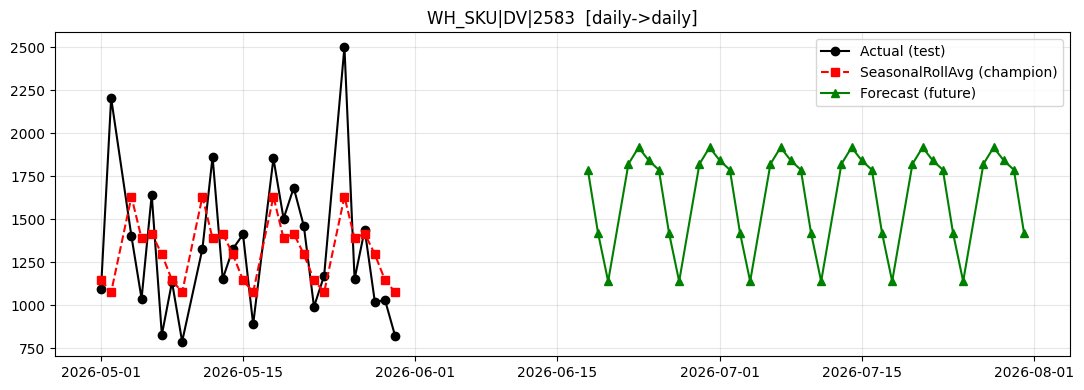

In [ ]:
if not BACKTEST.empty:
    ex = CHAMPIONS["series"].iloc[0]; champ = CHAMPIONS["model"].iloc[0]
    sub = BACKTEST[(BACKTEST.series==ex)&(BACKTEST.model==champ)].sort_values("period")
    fig, ax = plt.subplots(figsize=(11,4))
    ax.plot(sub.period, sub.actual, "k-o", label="Actual (test)")
    ax.plot(sub.period, sub.pred, "r--s", label=f"{champ} (champion)")
    fcw = FORECAST_CHAMPION[FORECAST_CHAMPION.series==ex].sort_values("period")
    if not fcw.empty: ax.plot(fcw.period, fcw.forecast, "g-^", label="Forecast (future)")
    ax.set_title(f"{ex}  [{CFG['TEMPORAL_AGG']}->{CFG['FORECAST_AGG']}]"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 12 · Export to Excel

In [ ]:
run_cfg = pd.DataFrame({"parameter": ["level","temporal_agg","forecast_agg","test_window",
        "forecast_window","select_metric","pre_transform","n_combinations","data_range"],
    "value": [LEVEL, TEMPORAL, FGRAIN, f"{TEST_START.date()}..{TEST_END.date()}",
              f"{FC_START.date()}..{FC_END.date()}", METRIC, TRANSFORM, len(COMBOS),
              f"{demand.date.min().date()}..{REF_DATE.date()}"]})
with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as xl:
    run_cfg.to_excel(xl, sheet_name="Run_Config", index=False)
    if not CHAMPIONS.empty: CHAMPIONS.round(4).to_excel(xl, sheet_name="Champions", index=False)
    if not LEADER.empty:    LEADER.round(4).to_excel(xl, sheet_name="Leaderboard", index=False)
    if not FORECAST_CHAMPION.empty:
        FORECAST_CHAMPION.round(2).to_excel(xl, sheet_name="Forecast_Champion", index=False)
    if not FORECASTS.empty: FORECASTS.round(2).to_excel(xl, sheet_name="Forecast_AllModels", index=False)
    if not BACKTEST.empty:  BACKTEST.round(2).to_excel(xl, sheet_name="Backtest_Detail", index=False)
    CLASSIF[LEVEL].round(4).to_excel(xl, sheet_name=("CL_"+LEVEL)[:31], index=False)
print("written ->", OUTPUT_FILE)
# from google.colab import files; files.download(OUTPUT_FILE)

written -> GrowSari_Forecast_v3_Output.xlsx


---
**Recap of the input contract**
- *Level* sets the required columns for the upload: `WH_SKU`→(warehouse_id, sku_id); `WH_SKU_Channel`→(+channel); `WH_Category`→(warehouse_id, category); `WH_Category_Channel`→(+channel). Header variants (e.g. `Warehouse`, `SKU`) are auto-mapped.
- *Test month(s)* must exist in history (they are scored). *Forecast window* may be future; the forecast is sliced to those month(s) at the chosen granularity.
- *Forecast granularity* is constrained to be ≥ the temporal aggregation.
